In [13]:
import xarray as xr
import pandas as pd
import numpy as np
import sys, os
import geopandas as gpd

import cartopy
import matplotlib.pyplot as plt
import cmocean.cm as cmo
from matplotlib.gridspec import GridSpec

# cartopy
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.feature import ShapelyFeature
from matplotlib.colorbar import Colorbar # different way to handle colorbar

sys.path.append('../modules')
from plotter import draw_basemap, plot_terrain
import customcmaps as ccmap
import globalvars

In [2]:
path_to_out = '../out/'
path_to_figs = '../figs/'

In [3]:
fp = globalvars.path_to_data + 'downloads/WBD_14_HU2/WBDHU2.shp'
HU2_poly = gpd.read_file(fp)
HU2_poly = HU2_poly.to_crs(epsg=4326)

In [4]:
percentile=90
fname = os.path.join(path_to_out, f"AR_fraction_{percentile}-percentile_SWE_SNOTEL.csv")
df = pd.read_csv(fname)
df.sort_values(by='AR_fraction_extreme_SWE')

,station,latitude,longitude,elevation,lat,lev,ens,lon,AR_fraction_extreme_SWE
30,522:UT:SNTL,40.90663,-109.96287,9120.0,41.00,0.0,1.0,-110.00,20.276100
31,528:UT:SNTL,40.92167,-110.18623,9170.0,41.00,0.0,1.0,-110.25,25.761773
29,521:UT:SNTL,40.95009,-110.48419,9510.0,41.00,0.0,1.0,-110.50,28.709918
1,335:CO:SNTL,39.80364,-105.77786,11300.0,39.75,0.0,1.0,-105.75,33.266291
8,378:CO:SNTL,39.87504,-107.59902,9290.0,40.00,0.0,1.0,-107.50,35.369775
...,...,...,...,...,...,...,...,...,...
64,720:UT:SNTL,40.54875,-110.69292,7880.0,40.50,0.0,1.0,-110.75,74.614472
84,843:CO:SNTL,37.48524,-107.50748,10740.0,37.50,0.0,1.0,-107.50,75.143560
82,840:CO:SNTL,37.48563,-106.83528,10140.0,37.50,0.0,1.0,-106.75,75.403123
72,780:CO:SNTL,37.69883,-107.77841,10660.0,37.75,0.0,1.0,-107.75,78.715919


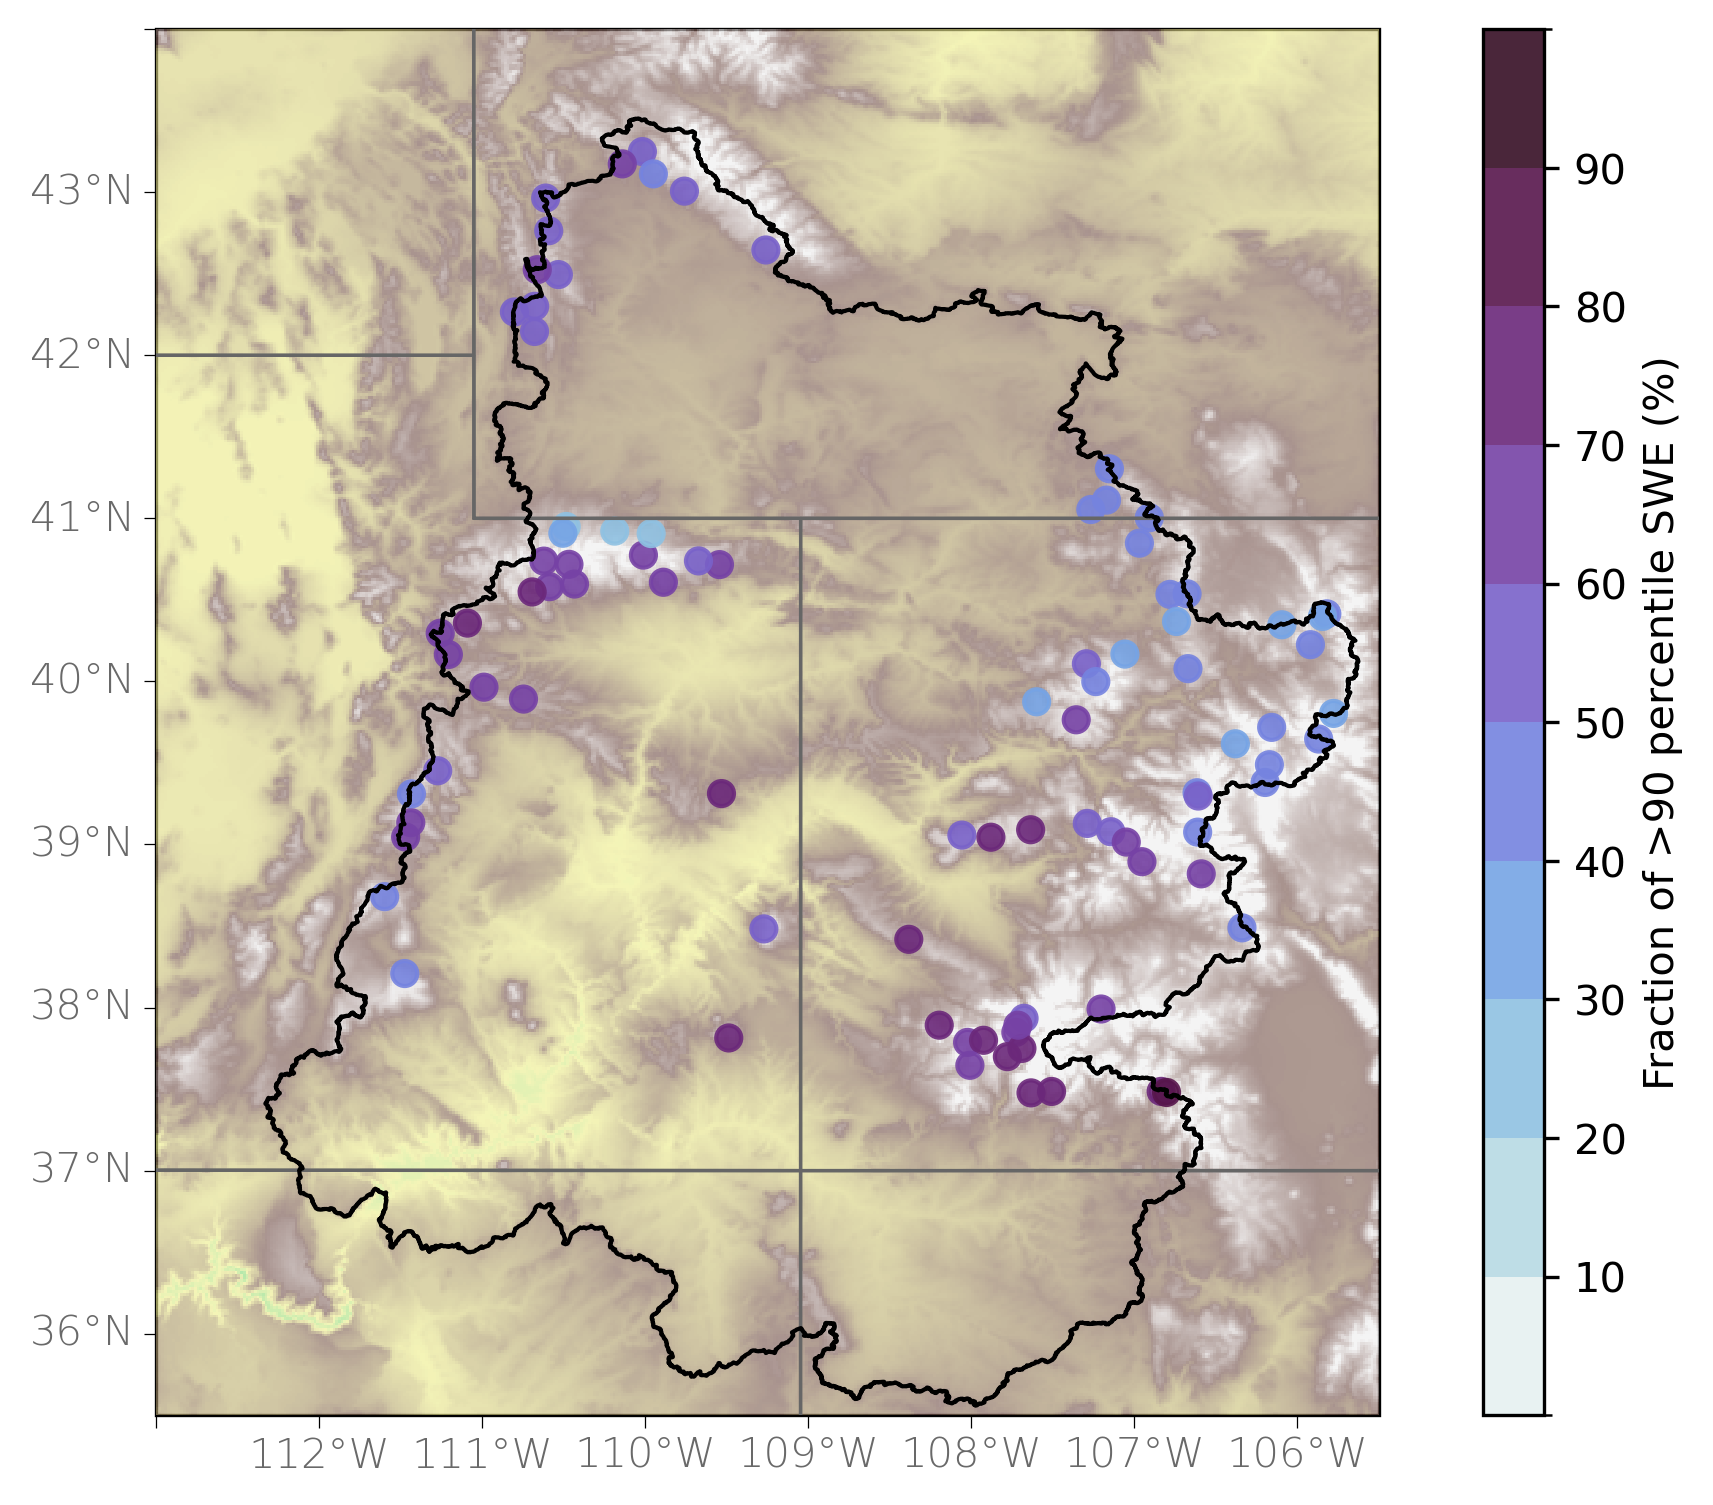

In [18]:
# Set up projection
datacrs = ccrs.PlateCarree()  ## the projection the data is in
mapcrs = ccrs.PlateCarree() ## the projection you want your map displayed in

# Set tick/grid locations
ext1 = [-113, -105.5, 35.5, 44.] # extent of CO
dx = np.arange(-113., -105.,1)
dy = np.arange(36, 45,1)

# Create figure
fig = plt.figure(figsize=(6., 6))
fig.dpi = 300
fname = path_to_figs + f'AR_contribution_SNOTEL_{percentile}-percentile'
fmt = 'png'

# Grid layout
gs = GridSpec(
    1,
    2,
    height_ratios=[1],
    width_ratios=[1, 0.05],
    wspace=0.15,
    hspace=0.03,
)

# Add color bar axis
cbax = fig.add_subplot(gs[0,-1])

## Add axis for plot
ax = fig.add_subplot(gs[0,0], projection=mapcrs)
ax = draw_basemap(ax, extent=ext1, xticks=dx, yticks=dy,left_lats=True, right_lats=False, bottom_lons=True, mask_ocean=False, coastline=False)

# topo with gray shading
cs = plot_terrain(ax, ext1, vmax=3500, greyscale=False)

# add choropleth watershed fraction
cbarticks = [10, 20, 30, 40, 50, 60, 70, 80, 90]
cmap, norm, bnds = ccmap.cmap_segmented(cmo.dense, np.arange(0, 110, 10))
col_name = 'AR_fraction_extreme_SWE'
sc = ax.scatter(
    df['longitude'],
    df['latitude'],
    c=df[col_name],
    cmap=cmap,
    norm=norm,
    alpha=0.9,
    transform=datacrs,   # <-- critical for Cartopy
    zorder=101,
)

cbar = plt.colorbar(sc, cax=cbax)
cbar.set_label(f"Fraction of >{percentile} percentile SWE (%)")
cbar.set_ticks(cbarticks)

ax.add_feature(cfeature.STATES, edgecolor='0.4', linewidth=0.8, zorder=199)

# Plot HU2
HU2_poly.crs = 'epsg:4326'
feature = ShapelyFeature(HU2_poly.geometry, ccrs.PlateCarree(),
                         edgecolor='k', facecolor='none', linewidth=1.)
ax.add_feature(feature, zorder=200)

        
fig.savefig('%s.%s' %(fname, fmt), bbox_inches='tight', dpi=fig.dpi)

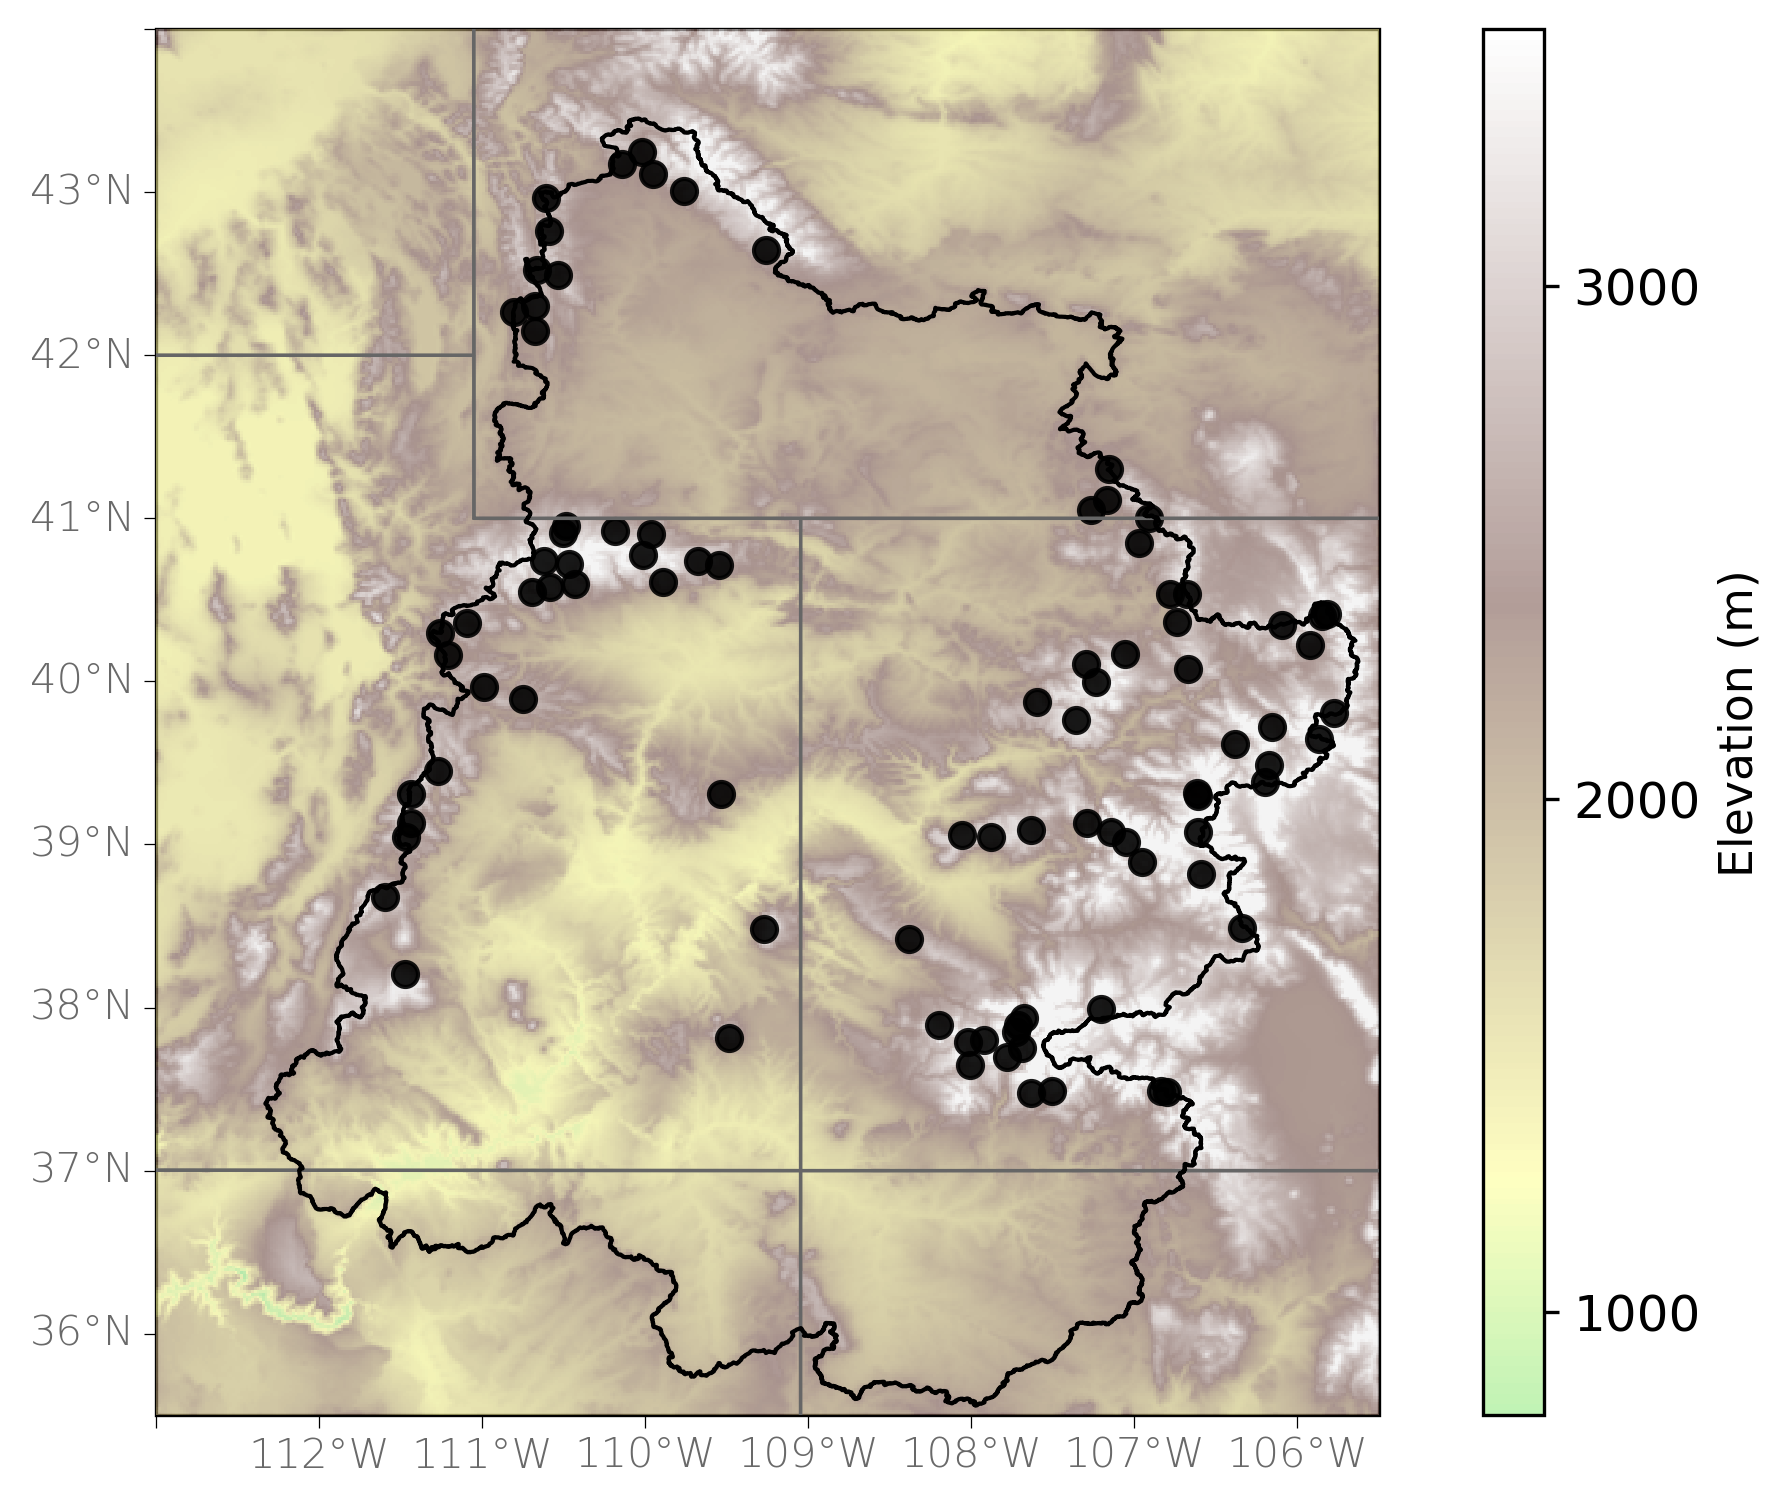

In [17]:
# Set up projection
datacrs = ccrs.PlateCarree()  ## the projection the data is in
mapcrs = ccrs.PlateCarree() ## the projection you want your map displayed in

# Set tick/grid locations
ext1 = [-113, -105.5, 35.5, 44.] # extent of CO
dx = np.arange(-113., -105.,1)
dy = np.arange(36, 45,1)

# Create figure
fig = plt.figure(figsize=(6., 6))
fig.dpi = 300
fname = path_to_figs + f'topographic_map'
fmt = 'png'

# Grid layout
gs = GridSpec(
    1,
    2,
    height_ratios=[1],
    width_ratios=[1, 0.05],
    wspace=0.15,
    hspace=0.03,
)

# Add color bar axis
cbax = fig.add_subplot(gs[0,-1])

## Add axis for plot
ax = fig.add_subplot(gs[0,0], projection=mapcrs)
ax = draw_basemap(ax, extent=ext1, xticks=dx, yticks=dy,left_lats=True, right_lats=False, bottom_lons=True, mask_ocean=False, coastline=False)

# topo with gray shading
ax, cs = plot_terrain(ax, ext1, vmax=3500, greyscale=False)

# add SNOTEL locations
sc = ax.scatter(
    df['longitude'],
    df['latitude'],
    c='k',
    alpha=0.9,
    transform=datacrs,   # <-- critical for Cartopy
    zorder=101,
)


# cbar = plt.colorbar(cs, cax=cbax)
# cbar.set_label(f'Elevation (m)')
# cbarticks = [0, 1000, 2000, 3000] 
# cbar.set_ticks(cbarticks)

cbarticks = [0, 1000, 2000, 3000]           
cb = Colorbar(ax = cbax, mappable = cs, orientation = 'vertical', ticklocation = 'right', ticks=cbarticks)
cb.set_label('Elevation (m)', fontsize=11)
cb.ax.tick_params(labelsize=12)

ax.add_feature(cfeature.STATES, edgecolor='0.4', linewidth=0.8, zorder=199)

# Plot HU2
HU2_poly.crs = 'epsg:4326'
feature = ShapelyFeature(HU2_poly.geometry, ccrs.PlateCarree(),
                         edgecolor='k', facecolor='none', linewidth=1.)
ax.add_feature(feature, zorder=200)

        
fig.savefig('%s.%s' %(fname, fmt), bbox_inches='tight', dpi=fig.dpi)